# Logistic Regression – Age vs Survival (Sigmoid Plot)
**Dataset:** Titanic  
**X-axis:** Passenger Age  
**Y-axis:** P(Survived)  
**Model:** Logistic Regression with Sigmoid Function

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## 1. Load & Preprocess Data

In [2]:
titanic = pd.read_csv('Titanic-Dataset.csv')
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())
print(f'Dataset shape: {titanic.shape}')
titanic[['Age', 'Survived']].describe()

Dataset shape: (891, 12)


,Age,Survived
count,891.000000,891.000000
mean,29.361582,0.383838
std,13.019697,0.486592
min,0.420000,0.000000
25%,22.000000,0.000000
50%,28.000000,0.000000
75%,35.000000,1.000000
max,80.000000,1.000000


## 2. Train Logistic Regression (Age → Survived)

In [3]:
X = titanic[['Age']].values
y = titanic['Survived'].values

model = LogisticRegression()
model.fit(X, y)

coef      = model.coef_[0][0]
intercept = model.intercept_[0]

print(f'Coefficient (Age) : {coef:.6f}')
print(f'Intercept         : {intercept:.6f}')
print(f'Sigmoid formula   : z = {coef:.4f} * Age + ({intercept:.4f})')
print(f'Training Accuracy : {accuracy_score(y, model.predict(X)):.2f}')

Coefficient (Age) : -0.010396
Intercept         : -0.170249
Sigmoid formula   : z = -0.0104 * Age + (-0.1702)
Training Accuracy : 0.62


## 3. Sigmoid Function

In [4]:
def sigmoid(z):
    """Standard sigmoid / logistic function."""
    return 1 / (1 + np.exp(-z))

# Generate smooth age range for the curve
age_range = np.linspace(0, 80, 300)
z_values  = coef * age_range + intercept
prob_curve = sigmoid(z_values)

# Preview a few key ages
sample_ages = [0, 10, 20, 30, 40, 50, 60, 70, 80]
print(f'{"Age":>5}  {"z":>8}  {"P(Survived)":>12}')
print('-' * 30)
for age in sample_ages:
    z = coef * age + intercept
    p = sigmoid(z)
    print(f'{age:>5}  {z:>8.4f}  {p:>12.4f}')

  Age         z   P(Survived)
------------------------------
    0   -0.1702        0.4575
   10   -0.2742        0.4319
   20   -0.3782        0.4066
   30   -0.4821        0.3817
   40   -0.5861        0.3575
   50   -0.6901        0.3340
   60   -0.7940        0.3113
   70   -0.8980        0.2895
   80   -1.0019        0.2686


## 4. Compute Actual Survival Rate per Age Bin

In [5]:
bins      = range(0, 85, 5)
bin_ages, bin_rates, bin_sizes = [], [], []

for start in list(bins)[:-1]:
    end    = start + 5
    mask   = (titanic['Age'] >= start) & (titanic['Age'] < end)
    subset = titanic[mask]
    if len(subset) >= 3:
        bin_ages.append((start + end) / 2)
        bin_rates.append(subset['Survived'].mean())
        bin_sizes.append(len(subset))

bin_ages  = np.array(bin_ages)
bin_rates = np.array(bin_rates)
bin_sizes = np.array(bin_sizes)

print(f'{"Age Bin":>10}  {"Actual Rate":>12}  {"n":>6}')
print('-' * 32)
for a, r, n in zip(bin_ages, bin_rates, bin_sizes):
    print(f'{a-2.5:.0f}–{a+2.5:.0f}:  {r:>12.3f}  {n:>6}')

   Age Bin   Actual Rate       n
--------------------------------
0–5:         0.675      40
5–10:         0.500      22
10–15:         0.438      16
15–20:         0.395      86
20–25:         0.342     114
25–30:         0.318     283
30–35:         0.421      95
35–40:         0.458      72
40–45:         0.375      48
45–50:         0.390      41
50–55:         0.438      32
55–60:         0.375      16
60–65:         0.400      15
65–70:         0.000       4
70–75:         0.000       6


## 5. Plot – Sigmoid Curve + Raw Scatter + Binned Rates

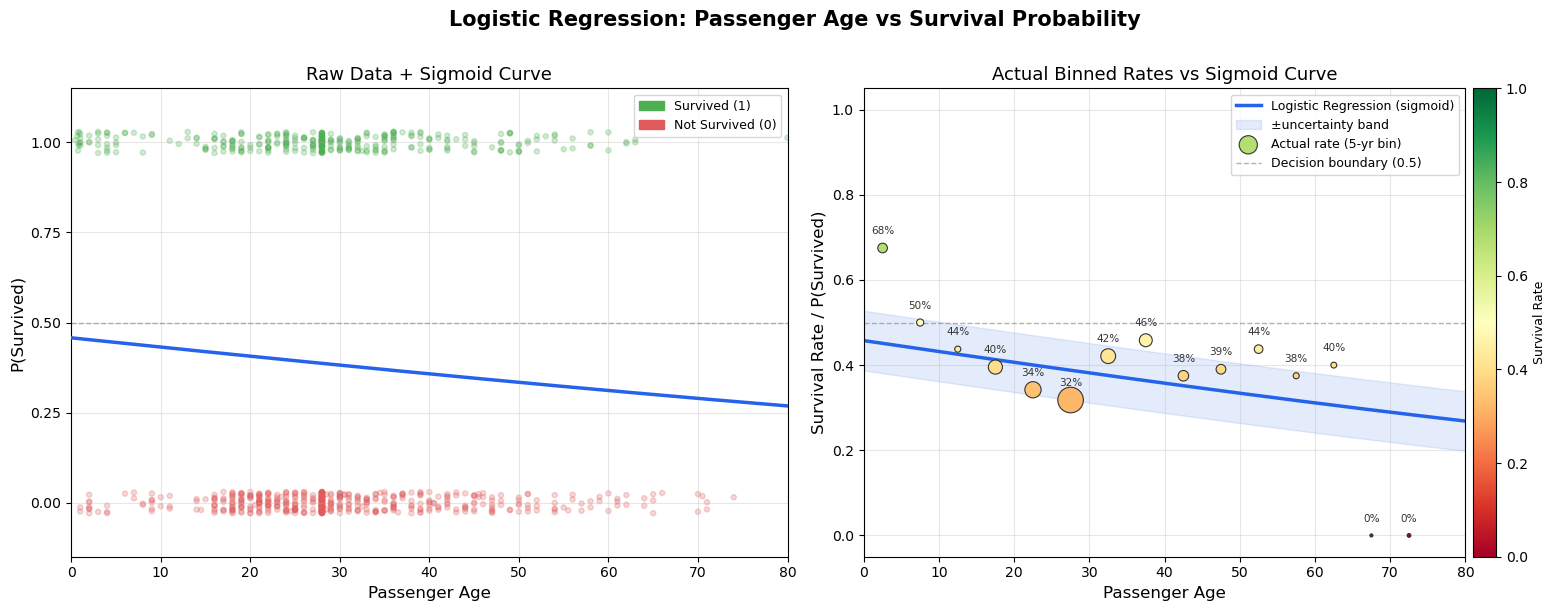

Plot saved as logistic_sigmoid_plot.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Logistic Regression: Passenger Age vs Survival Probability',
    fontsize=15, fontweight='bold', y=1.01
)

# ── Left: raw scatter + sigmoid ──────────────────────────────────────────────
ax1 = axes[0]

# Jitter survived/not-survived points so they don't stack on y=0/1
np.random.seed(42)
jitter = np.random.uniform(-0.03, 0.03, size=len(titanic))

colors = titanic['Survived'].map({0: '#e05c5c', 1: '#4caf50'})
ax1.scatter(
    titanic['Age'], titanic['Survived'] + jitter,
    c=colors, alpha=0.25, s=14, zorder=1
)

# Sigmoid curve
ax1.plot(
    age_range, prob_curve,
    color='#2563eb', linewidth=2.5, zorder=3,
    label=f'Sigmoid: 1/(1+e^-z)\nz = {coef:.4f}×Age + ({intercept:.4f})'
)

ax1.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Decision boundary (0.5)')

ax1.set_xlabel('Passenger Age', fontsize=12)
ax1.set_ylabel('P(Survived)', fontsize=12)
ax1.set_title('Raw Data + Sigmoid Curve', fontsize=13)
ax1.set_ylim(-0.15, 1.15)
ax1.set_xlim(0, 80)
ax1.set_yticks([0, 0.25, 0.5, 0.75, 1.0])

survived_patch    = mpatches.Patch(color='#4caf50', label='Survived (1)')
not_survived_patch = mpatches.Patch(color='#e05c5c', label='Not Survived (0)')
ax1.legend(handles=[survived_patch, not_survived_patch], loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# ── Right: binned actual rates + sigmoid ─────────────────────────────────────
ax2 = axes[1]

# Sigmoid curve
ax2.plot(
    age_range, prob_curve,
    color='#2563eb', linewidth=2.5, zorder=2,
    label='Logistic Regression (sigmoid)'
)

# Shaded confidence band (±1 std of bin rate, weighted)
ax2.fill_between(
    age_range, prob_curve - 0.07, prob_curve + 0.07,
    alpha=0.12, color='#2563eb', label='±uncertainty band'
)

# Binned actual rates (bubble size ∝ n)
scatter = ax2.scatter(
    bin_ages, bin_rates,
    s=bin_sizes * 1.2,
    c=bin_rates, cmap='RdYlGn', vmin=0, vmax=1,
    edgecolors='#333', linewidths=0.8,
    zorder=3, label='Actual rate (5-yr bin)'
)

ax2.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Decision boundary (0.5)')

# Annotate each bubble with the survival %
for age, rate, n in zip(bin_ages, bin_rates, bin_sizes):
    ax2.annotate(
        f'{rate*100:.0f}%',
        xy=(age, rate), xytext=(0, 10),
        textcoords='offset points', ha='center',
        fontsize=7.5, color='#333'
    )

ax2.set_xlabel('Passenger Age', fontsize=12)
ax2.set_ylabel('Survival Rate / P(Survived)', fontsize=12)
ax2.set_title('Actual Binned Rates vs Sigmoid Curve', fontsize=13)
ax2.set_ylim(-0.05, 1.05)
ax2.set_xlim(0, 80)
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax2, pad=0.01)
cbar.set_label('Survival Rate', fontsize=9)

plt.tight_layout()
plt.savefig('logistic_sigmoid_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as logistic_sigmoid_plot.png')

## 6. Sigmoid Formula Summary

In [7]:
print('=' * 50)
print('  LOGISTIC REGRESSION – SIGMOID SUMMARY')
print('=' * 50)
print(f'  Formula : P(Survived) = 1 / (1 + e^(-z))')
print(f'  where   : z = {coef:.4f} * Age + ({intercept:.4f})')
print()
print(f'  Interpretation:')
print(f'  - Each additional year of age changes log-odds by {coef:.4f}')
print(f'  - Negative coeff → older passengers less likely to survive')
print(f'  - P(child age 5)  = {sigmoid(coef*5  + intercept):.3f}')
print(f'  - P(adult age 30) = {sigmoid(coef*30 + intercept):.3f}')
print(f'  - P(elder age 65) = {sigmoid(coef*65 + intercept):.3f}')
print()
print(f'  Note: Age alone is a weak predictor (accuracy ≈ {accuracy_score(y, model.predict(X)):.2f})')
print(f'  Sex and Pclass explain much more variance.')
print('=' * 50)

  LOGISTIC REGRESSION – SIGMOID SUMMARY
  Formula : P(Survived) = 1 / (1 + e^(-z))
  where   : z = -0.0104 * Age + (-0.1702)

  Interpretation:
  - Each additional year of age changes log-odds by -0.0104
  - Negative coeff → older passengers less likely to survive
  - P(child age 5)  = 0.445
  - P(adult age 30) = 0.382
  - P(elder age 65) = 0.300

  Note: Age alone is a weak predictor (accuracy ≈ 0.62)
  Sex and Pclass explain much more variance.
